## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D)

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들)
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

In [25]:
DATA_DIR = "./data/"

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

#train data는 overfitting을 막기 위해 augmentation함.
full_train_aug = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=transform_train)
full_train_plain = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=transform_eval)
test_data = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=transform_eval)

n_total = len(full_train_aug)
n_val = int(n_total * 0.1)

#train eval split하기 위한 permutation
g = torch.Generator().manual_seed(42)
perm = torch.randperm(n_total, generator=g).tolist()
val_idx, train_idx = perm[:n_val], perm[n_val:]

#train val split. val은 not aug 데이터에서 추출.
train_data = Subset(full_train_aug, train_idx)
val_data = Subset(full_train_plain, val_idx)

BATCH_SIZE = 256
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"train: {len(train_data)}, val: {len(val_data)}, test: {len(test_data)}")

train: 54000, val: 6000, test: 10000


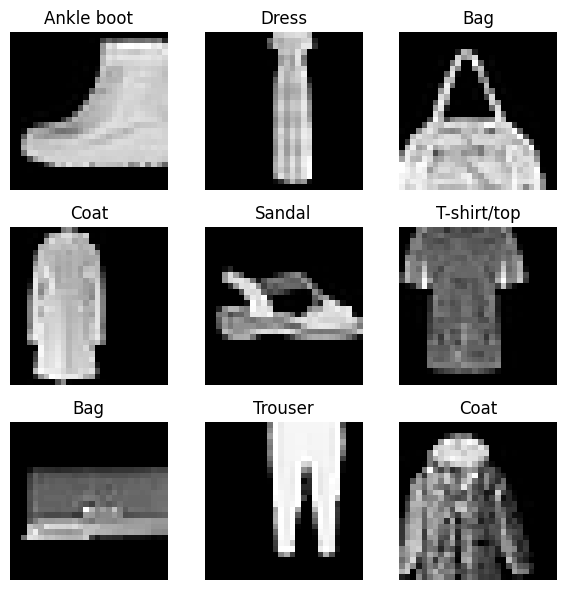

In [27]:
#image data glimpse - fashion mnist

classes = full_train_aug.classes

plt.figure(figsize=(6, 6))
for i in range(9):
    img, label = train_data[i]
    plt.subplot(3, 3, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(classes[label])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [28]:
#이미지 크기 확인
img, label = train_data[0]
print(f"train sample: {img.shape}, dtype={img.dtype}, label={label}")
img, label = test_data[0]
print(f"test sample: {img.shape}, dtype={img.dtype}, label={label}")

train sample: torch.Size([1, 28, 28]), dtype=torch.float32, label=9
train sample: torch.Size([1, 28, 28]), dtype=torch.float32, label=9


### Basic Mmodeling

In [29]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        '''
        nn.Sequential 로 각 레이어를 묶어서 하나의 모델로 정의할 수도 있습니다!

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        '''

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

        # return self.model(x)

In [32]:
class CNN(nn.Module):
    def __init__(self, num_classes=10): # 클래스의 갯수
        super(CNN, self).__init__()

        # CNN 블럭 정의
        self.block1 = BasicBlock(in_channels=1, out_channels=32, hidden_dim=16)
        #크기가 28-> 14
        self.block2 = BasicBlock(in_channels=32, out_channels=64, hidden_dim=32)
        #크기가 14-> 7

        # classification을 위한 FC 정의
        self.fc1 = nn.Linear(in_features=3136, out_features=256) # Changed from 4096 to 2304
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = torch.flatten(x, start_dim=1) # 2차원의 feature map을 1차원으로

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)

        return x


In [33]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
model1 = CNN().to(device)
print(f"Model1 params: {sum(p.numel() for p in model1.parameters()):,}")

device: cpu
Model1 params: 838,186


## Batch norm, Dropout 추가



In [43]:
class RegBlock(nn.Module):
    def __init__(self, input_ch, output_ch, hidden_ch, drop_p):
        super().__init__()
        self.conv1 = nn.Conv2d(input_ch, hidden_ch, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(hidden_ch)
        self.conv2 = nn.Conv2d(hidden_ch, output_ch, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(output_ch)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop = nn.Dropout2d(drop_p)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        return self.drop(x)


class RegCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = RegBlock(1, 16, 32, 0.1)
        self.block2 = RegBlock(16, 32, 64, 0.2)
        self.fc1 = nn.Linear(32 * 7 * 7, 256) # Corrected in_features from 64*7*7 to 32*7*7
        self.bn_fc = nn.BatchNorm1d(256)
        self.drop_fc = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = torch.flatten(x, 1)
        x = self.relu(self.bn_fc(self.fc1(x)))
        x = self.drop_fc(x)
        return self.fc2(x)


model2 = RegCNN().to(device)
print(f"Model2 params: {sum(p.numel() for p in model2.parameters()):,}")

Model2 params: 437,722


## Batchnorm, AdamW , Early stopping 추가 / Max pool 대신 stride=2 사용

In [46]:
import copy

class DeepCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = RegBlock(1, 16, 32, 0.1)   # 28 -> 14
        self.block2 = RegBlock(16, 32, 64, 0.2)  # 14 -> 7

        # block3: MaxPool 대신 stride=2 conv로 다운샘플링
        self.conv3a = nn.Conv2d(32, 64, kernel_size=3, padding=1) # Corrected in_channels from 64 to 32
        self.bn3a = nn.BatchNorm2d(64)
        self.conv3b = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)  # 7 -> 4
        self.bn3b = nn.BatchNorm2d(128)
        self.drop3 = nn.Dropout2d(0.3)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.drop_fc = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.relu(self.bn3a(self.conv3a(x)))
        x = self.relu(self.bn3b(self.conv3b(x)))
        x = self.drop3(x)
        x = torch.flatten(x, 1)
        x = self.relu(self.bn_fc(self.fc1(x)))
        x = self.drop_fc(x)
        return self.fc2(x)


class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            self.should_stop = self.counter >= self.patience
        return self.should_stop

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


model3 = DeepCNN().to(device)
print(f"Model3 params: {sum(p.numel() for p in model3.parameters()):,}")

Model3 params: 653,338


In [36]:

def evaluate(model, loader, return_loss=False):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    correct, total_loss = 0, 0.0
    for data, label in loader:
        data, label = data.to(device), label.to(device)
        preds = model(data)
        if return_loss:
            total_loss += criterion(preds, label).item() * data.size(0)
        correct += preds.argmax(1).eq(label).sum().item()
    acc = correct / len(loader.dataset)
    if return_loss:
        return total_loss / len(loader.dataset), acc
    return acc


def train_one_model(model, optimizer, epochs, scheduler=None, early_stopper=None, name="model"):
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for data, label in tqdm(train_loader, desc=f"[{name}] epoch {epoch + 1}/{epochs}"):
            data, label = data.to(device), label.to(device)
            optimizer.zero_grad()
            preds = model(data)
            loss = criterion(preds, label)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * data.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        val_loss, val_acc = evaluate(model, val_loader, return_loss=True)

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"[{name}] epoch {epoch + 1}/{epochs} - train_loss {train_loss:.4f}  val_loss {val_loss:.4f}  val_acc {val_acc:.4f}")

        if early_stopper is not None and early_stopper.step(val_loss, model):
            print(f"[{name}] EarlyStopping: epoch {epoch + 1}에서 종료 (best val_loss={early_stopper.best_loss:.4f})")
            break

    if early_stopper is not None:
        early_stopper.restore(model)

    return history

## Train the models

model 1 기본

In [37]:
EPOCHS_1 = 7
optim1 = Adam(model1.parameters(), lr=1e-3)
history1 = train_one_model(model1, optim1, EPOCHS_1, name="Model1-Plain")

[Model1-Plain] epoch 1/7: 100%|██████████| 211/211 [02:14<00:00,  1.57it/s]


[Model1-Plain] epoch 1/7 - train_loss 1.3144  val_loss 0.9931  val_acc 0.6570


[Model1-Plain] epoch 2/7: 100%|██████████| 211/211 [02:09<00:00,  1.63it/s]


[Model1-Plain] epoch 2/7 - train_loss 0.9515  val_loss 0.9370  val_acc 0.6657


[Model1-Plain] epoch 3/7: 100%|██████████| 211/211 [02:05<00:00,  1.68it/s]


...

[Model1-Plain] epoch 5/7 - train_loss 0.8162  val_loss 0.8242  val_acc 0.6917


[Model1-Plain] epoch 6/7: 100%|██████████| 211/211 [02:05<00:00,  1.68it/s]


[Model1-Plain] epoch 6/7 - train_loss 0.7902  val_loss 0.7822  val_acc 0.7012


[Model1-Plain] epoch 7/7: 100%|██████████| 211/211 [02:08<00:00,  1.64it/s]


[Model1-Plain] epoch 7/7 - train_loss 0.7769  val_loss 0.7690  val_acc 0.7087


model 2 (batch norm, dropout)

In [45]:
EPOCHS_2 = 7
optim2 = Adam(model2.parameters(), lr=1e-3)
history2 = train_one_model(model2, optim2, EPOCHS_2, name="Model2-Reg")

[Model2-Reg] epoch 1/7: 100%|██████████| 211/211 [02:17<00:00,  1.53it/s]


[Model2-Reg] epoch 1/7 - train_loss 0.7669  val_loss 0.4530  val_acc 0.8247


[Model2-Reg] epoch 2/7: 100%|██████████| 211/211 [02:15<00:00,  1.55it/s]


[Model2-Reg] epoch 2/7 - train_loss 0.5100  val_loss 0.3647  val_acc 0.8630


[Model2-Reg] epoch 3/7: 100%|██████████| 211/211 [02:18<00:00,  1.53it/s]


...

[Model2-Reg] epoch 5/7 - train_loss 0.3878  val_loss 0.2956  val_acc 0.8912


[Model2-Reg] epoch 6/7: 100%|██████████| 211/211 [02:14<00:00,  1.57it/s]


[Model2-Reg] epoch 6/7 - train_loss 0.3639  val_loss 0.2832  val_acc 0.8950


[Model2-Reg] epoch 7/7: 100%|██████████| 211/211 [02:16<00:00,  1.55it/s]


[Model2-Reg] epoch 7/7 - train_loss 0.3554  val_loss 0.2766  val_acc 0.8988


model 3 (Batchnorm, AdamW , Early stopping 추가 / Max pool 대신 stride=2 사용)

In [47]:
EPOCHS_3 = 12
optim3 = torch.optim.AdamW(model3.parameters(), lr=1e-3, weight_decay=1e-4)
stopper3 = EarlyStopping(patience=3)
history3 = train_one_model(model3, optim3, EPOCHS_3, early_stopper=stopper3, name="Model3-Deep")

[Model3-Deep] epoch 1/12: 100%|██████████| 211/211 [02:36<00:00,  1.34it/s]


[Model3-Deep] epoch 1/12 - train_loss 0.7824  val_loss 0.4721  val_acc 0.8253


[Model3-Deep] epoch 2/12: 100%|██████████| 211/211 [02:40<00:00,  1.31it/s]


[Model3-Deep] epoch 2/12 - train_loss 0.5070  val_loss 0.3733  val_acc 0.8588


[Model3-Deep] epoch 3/12: 100%|██████████| 211/211 [02:42<00:00,  1.30it/s]


...

[Model3-Deep] epoch 10/12 - train_loss 0.3167  val_loss 0.2467  val_acc 0.9082


[Model3-Deep] epoch 11/12: 100%|██████████| 211/211 [02:48<00:00,  1.25it/s]


[Model3-Deep] epoch 11/12 - train_loss 0.3041  val_loss 0.2372  val_acc 0.9112


[Model3-Deep] epoch 12/12: 100%|██████████| 211/211 [02:38<00:00,  1.33it/s]


[Model3-Deep] epoch 12/12 - train_loss 0.2996  val_loss 0.2340  val_acc 0.9147


## 결과분석

In [48]:
import pandas as pd

results = []
histories = {"Model1-Plain": history1, "Model2-Reg": history2, "Model3-Deep": history3}
models = {"Model1-Plain": model1, "Model2-Reg": model2, "Model3-Deep": model3}

for name, model in models.items():
    history = histories[name]
    test_acc = evaluate(model, test_loader)
    results.append({
        "model": name,
        "epochs_trained": len(history["train_loss"]),
        "best_val_loss": min(history["val_loss"]),
        "best_val_acc": max(history["val_acc"]),
        "test_acc": test_acc,
        "params": sum(p.numel() for p in model.parameters()),
    })

results_df = pd.DataFrame(results)
results_df

,model,epochs_trained,best_val_loss,best_val_acc,test_acc,params
0,Model1-Plain,7,0.768988,0.708667,0.7182,838186
1,Model2-Reg,7,0.276628,0.898833,0.8977,437722
2,Model3-Deep,12,0.234047,0.914667,0.9107,653338


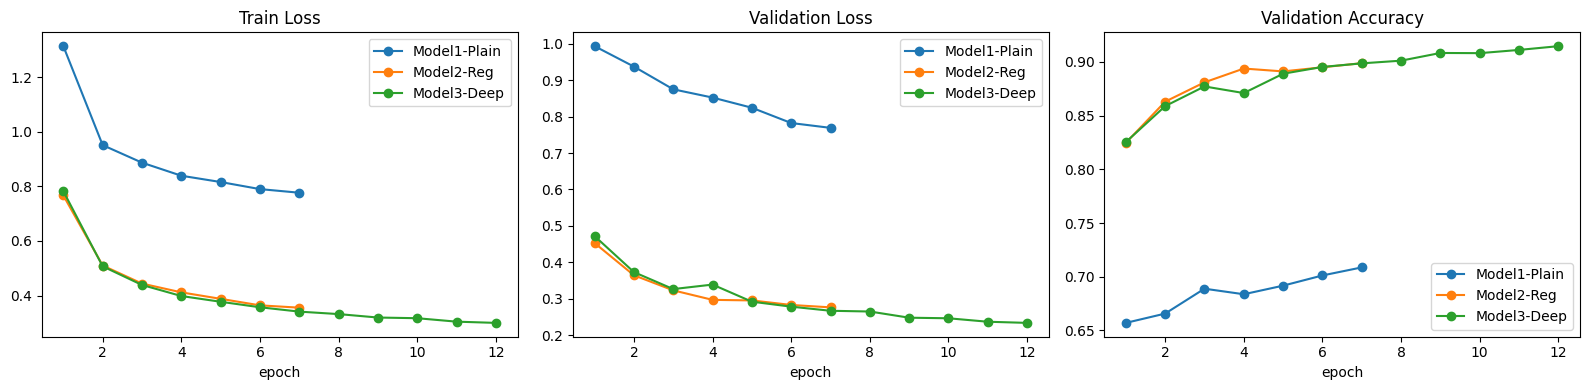

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for name, h in histories.items():
    axes[0].plot(range(1, len(h["train_loss"]) + 1), h["train_loss"], marker="o", label=name)
axes[0].set_title("Train Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

for name, h in histories.items():
    axes[1].plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], marker="o", label=name)
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("epoch")
axes[1].legend()

for name, h in histories.items():
    axes[2].plot(range(1, len(h["val_acc"]) + 1), h["val_acc"], marker="o", label=name)
axes[2].set_title("Validation Accuracy")
axes[2].set_xlabel("epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

## 분석

모든 평가지표(Train loss, Val loss, Val acc)에서 model1-baseline보다 model2 (Batch norm, Dropout 추가)가, model2보단 model3(Batchnorm, AdamW , Early stopping 추가 / Max pool 대신 stride=2 사용)가 더 좋은 성능을 나타내고 있다.


Colab 한도 제한으로 gpu를 사용할 수 없어 epoch을 많이 돌리지 못하였고, 그렇기에 model3에서 early stopping이 등장하지 않은 점이 아쉬움으로 남는다.